# Hei Njål
# ***I LOVE COCK***

In [2]:
print('U lost bbygurl?')

U lost bbygurl?


Importing required libraries and our dataset

In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from xgboost import XGBRegressor


df = pd.read_csv("../data/england-premier-league-matches-2018-to-2019-stats.csv")

Analyszing features

In [4]:
df.head()
# Identify odds-related columns
odds_columns = [col for col in df.columns if 'odds' in col.lower()]

# Identify pre-match columns
prematch_columns = [col for col in df.columns if 'pre' in col.lower() and 'match' in col.lower()]

# Remove columns with all null values
null_columns = [col for col in df.columns if (df[col] == 0).all()]

# Remove incomplete matches (if any)
not_completed = [col for col in df.columns if (df['status'] != 'complete').any()]



Data cleaning

In [5]:

#Remove all columns in the dataset that include odds. 
df_filtered = df.drop(columns = odds_columns)

# The first match 2 matches of the season has no 'pre-match' content, but are valued at 0, which could mess with this feature
df_filtered.loc[df['Game Week'] <= 2, prematch_columns] = np.nan

# Parse date_GMT into useful features
df_filtered['match_date'] = pd.to_datetime(df_filtered['date_GMT'], errors='coerce')
df_filtered['match_month'] = df_filtered['match_date'].dt.month
df_filtered['match_day'] = df_filtered['match_date'].dt.day
df_filtered['match_weekday'] = df_filtered['match_date'].dt.weekday
df_filtered = df_filtered.drop(columns=['date_GMT', 'match_date'])

# Remove the status, as all of the instances are complete, it's not important in this data set 
# Could be for coming matches, like a walkover, but then maybe you could just remove non-completed matches

df_filtered = df_filtered.drop(columns=['status'])

# Are they important?
df_filtered = df_filtered.drop(columns=['home_team_goal_timings', 'away_team_goal_timings'])


# Label encode categorical columns after handling missing values
categorical_columns = ['home_team_name', 'away_team_name', 'stadium_name', 'referee']

# Fill missing values with a placeholder (e.g., "Unknown")
for col in categorical_columns:
    df_filtered[col] = df_filtered[col].fillna("Unknown")

# Apply Label Encoding
label_encoders = {}  # Dictionary to store encoders for each column
for col in categorical_columns:
    le = LabelEncoder()
    df_filtered[col] = le.fit_transform(df_filtered[col].astype(str))  # Ensure strings for encoding
    label_encoders[col] = le  # Save the encoder for inverse transformation


# Fill missing values only for numeric columns
numeric_columns = df_filtered.select_dtypes(include=[np.number]).columns
df_filtered[numeric_columns] = df_filtered[numeric_columns].fillna(df_filtered[numeric_columns].mean())

df_filtered.sample(5)

C:\Users\sande\AppData\Local\Temp\ipykernel_26756\3174041481.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_filtered['match_date'] = pd.to_datetime(df_filtered['date_GMT'], errors='coerce')


,timestamp,attendance,home_team_name,away_team_name,referee,Game Week,Pre-Match PPG (Home),Pre-Match PPG (Away),home_ppg,away_ppg,...,over_15_HT_FHG_percentage_pre_match,over_05_HT_FHG_percentage_pre_match,over_15_2HG_percentage_pre_match,over_05_2HG_percentage_pre_match,average_corners_per_match_pre_match,average_cards_per_match_pre_match,stadium_name,match_month,match_day,match_weekday
39,1535900400,20141,17,16,0,4,3.00,3.00,1.42,1.74,...,25.0,50.0,50.0,75.0,10.50,5.50,18,9,2,6
241,1549119600,30414,2,17,16,25,1.64,1.33,1.21,1.21,...,35.0,78.0,30.0,79.0,9.42,4.67,15,2,2,5
38,1535900400,21525,3,13,7,4,0.00,0.00,1.21,1.58,...,100.0,100.0,50.0,100.0,10.00,2.00,17,9,2,6
258,1549805400,44154,16,10,12,26,2.00,1.38,2.00,1.32,...,24.0,76.0,48.0,80.0,11.37,2.69,20,2,10,6
30,1535801400,32149,10,11,14,4,3.00,3.00,1.42,2.32,...,50.0,100.0,0.0,50.0,8.00,5.00,7,9,1,5


#### Feature Importance Testing
Using the *Random Forest Regressor* for finding the feature importance

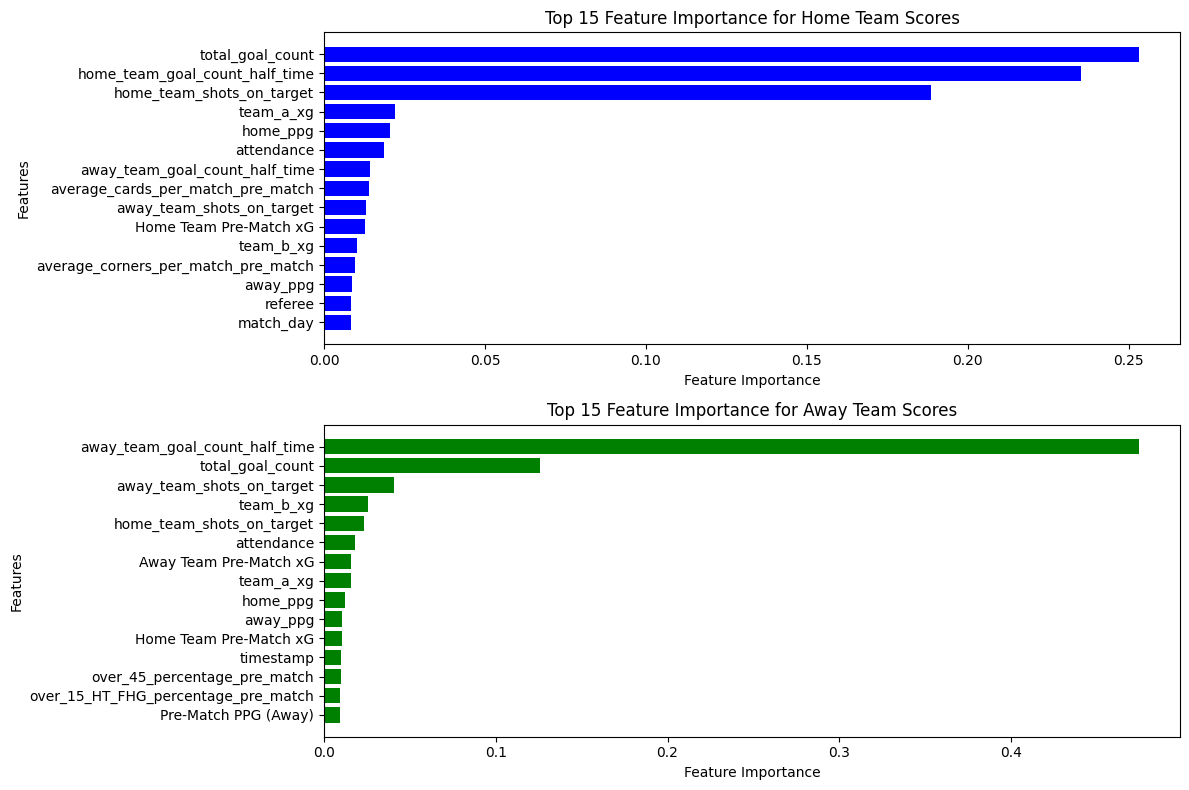

Feature Importance for 'home_team_name' in Home Team Scores: 0.00655
Feature Importance for 'home_team_name' in Away Team Scores: 0.00865


In [6]:


# Define feature and target columns
target_columns = ['home_team_goal_count', 'away_team_goal_count']
X = df_filtered.drop(columns=target_columns)
y_home = df_filtered['home_team_goal_count']
y_away = df_filtered['away_team_goal_count']

# Split dataset into train-test sets for home and away scores
X_train_home, X_test_home, y_train_home, y_test_home = train_test_split(X, y_home, test_size=0.2, random_state=42)
X_train_away, X_test_away, y_train_away, y_test_away = train_test_split(X, y_away, test_size=0.2, random_state=42)

# Train Random Forest models for home and away scores
rf_home = RandomForestRegressor(random_state=42)
rf_home.fit(X_train_home, y_train_home)

rf_away = RandomForestRegressor(random_state=42)
rf_away.fit(X_train_away, y_train_away)

# Extract feature importance for home and away scores
importances_home = rf_home.feature_importances_
importances_away = rf_away.feature_importances_

feature_importance_home_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances_home})
feature_importance_away_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances_away})

feature_importance_home_df.sort_values(by='Importance', ascending=False, inplace=True)
feature_importance_away_df.sort_values(by='Importance', ascending=False, inplace=True)


# Plot top 12 features for Home and Away Team Scores
top_n = 15  # Number of features to display

# Sort and select top features
top_features_home = feature_importance_home_df.head(top_n)
top_features_away = feature_importance_away_df.head(top_n)

plt.figure(figsize=(12, 8))

# Top 12 features for Home Team Scores
plt.subplot(2, 1, 1)
plt.barh(top_features_home['Feature'], top_features_home['Importance'], color='blue')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title(f'Top {top_n} Feature Importance for Home Team Scores')
plt.gca().invert_yaxis()

# Top 12 features for Away Team Scores
plt.subplot(2, 1, 2)
plt.barh(top_features_away['Feature'], top_features_away['Importance'], color='green')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title(f'Top {top_n} Feature Importance for Away Team Scores')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# Define the feature you want to check
feature_name = 'home_team_name'

# Find importance for home team scores
home_feature_importance = feature_importance_home_df.loc[
    feature_importance_home_df['Feature'] == feature_name, 'Importance'
].values

# Find importance for away team scores
away_feature_importance = feature_importance_away_df.loc[
    feature_importance_away_df['Feature'] == feature_name, 'Importance'
].values

# Display the results
if home_feature_importance.size > 0:
    print(f"Feature Importance for '{feature_name}' in Home Team Scores: {home_feature_importance[0]:.5f}")
else:
    print(f"Feature '{feature_name}' not found in Home Team Feature Importance.")

if away_feature_importance.size > 0:
    print(f"Feature Importance for '{feature_name}' in Away Team Scores: {away_feature_importance[0]:.5f}")
else:
    print(f"Feature '{feature_name}' not found in Away Team Feature Importance.")


Then we use *Recursive Feature Elimination* to select which features to carry on using. We will then have a list of features optimized for each score. We will use this to make better models, one for each score, and then we will try a MultiRegressor to compare how they perform.

In [7]:
# Recursive Feature Elimination (RFE) for Home Team Scores
rfe_home = RFE(estimator=rf_home, n_features_to_select=10)
rfe_home.fit(X_train_home, y_train_home)
selected_features_home = X.columns[rfe_home.support_]

# Recursive Feature Elimination (RFE) for Away Team Scores
rfe_away = RFE(estimator=rf_away, n_features_to_select=10)
rfe_away.fit(X_train_away, y_train_away)
selected_features_away = X.columns[rfe_away.support_]

# Print selected features
print("Selected Features for Home Team Scores using RFE:", selected_features_home)
print("Selected Features for Away Team Scores using RFE:", selected_features_away)

# Evaluate models on test data
y_pred_home = rf_home.predict(X_test_home)
y_pred_away = rf_away.predict(X_test_away)

# Metrics for Home Scores
print("\n--- Home Team Scores ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_home, y_pred_home)}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_home, y_pred_home)}")
print(f"R^2 Score: {r2_score(y_test_home, y_pred_home)}")

# Metrics for Away Scores
print("\n--- Away Team Scores ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_away, y_pred_away)}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_away, y_pred_away)}")
print(f"R^2 Score: {r2_score(y_test_away, y_pred_away)}")

Selected Features for Home Team Scores using RFE: Index(['attendance', 'home_ppg', 'total_goal_count',
       'home_team_goal_count_half_time', 'home_team_shots_on_target',
       'away_team_shots_on_target', 'Home Team Pre-Match xG', 'team_a_xg',
       'team_b_xg', 'average_cards_per_match_pre_match'],
      dtype='object')
Selected Features for Away Team Scores using RFE: Index(['timestamp', 'attendance', 'total_goal_count',
       'away_team_goal_count_half_time', 'home_team_shots_on_target',
       'away_team_shots_on_target', 'Home Team Pre-Match xG',
       'Away Team Pre-Match xG', 'team_a_xg', 'team_b_xg'],
      dtype='object')

--- Home Team Scores ---
Mean Absolute Error (MAE): 0.485
Mean Squared Error (MSE): 0.3667526315789474
R^2 Score: 0.7648353463587921

--- Away Team Scores ---
Mean Absolute Error (MAE): 0.5294736842105263
Mean Squared Error (MSE): 0.48208421052631595
R^2 Score: 0.534049799196787


### Using Gradient Boosting for Improved Performance
Gradient Boosting methods like XGBoost (eXtreme Gradient Boosting) often outperform Random Forest for structured/tabular data because:

- It optimizes each decision tree sequentially to reduce errors.
- It provides finer control over regularization and learning rates.

XGBoost is a machine learning algorithm based on gradient boosting, which builds decision trees sequentially to correct errors made by previous trees. It’s known for its speed, accuracy, and scalability.
- Boosting: Combines multiple weak models (trees) into a strong model.
- Gradient Descent: Optimizes the model by minimizing a loss function (e.g., Mean Squared Error).
- Regularization: Prevents overfitting using techniques like gamma and lambda.
- Efficiency: Parallel processing and optimized memory usage make it fast and scalable.
- High performance for structured/tabular data.
- Flexibility to handle regression, classification, and ranking tasks.
- Handles missing values automatically.

In [8]:
# Use RFE-selected features
X_train_home_rfe = X_train_home[selected_features_home]
X_test_home_rfe = X_test_home[selected_features_home]

X_train_away_rfe = X_train_away[selected_features_away]
X_test_away_rfe = X_test_away[selected_features_away]

# Initialize XGBoost models
xgb_home = XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_away = XGBRegressor(objective='reg:squarederror', random_state=42)

# Train models
xgb_home.fit(X_train_home_rfe, y_train_home)
xgb_away.fit(X_train_away_rfe, y_train_away)

# Make predictions
y_pred_home_xgb = xgb_home.predict(X_test_home_rfe)
y_pred_away_xgb = xgb_away.predict(X_test_away_rfe)

# Evaluate models
print("\n--- Home Team Scores (XGBoost) ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_home, y_pred_home_xgb)}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_home, y_pred_home_xgb)}")
print(f"R^2 Score: {r2_score(y_test_home, y_pred_home_xgb)}")

print("\n--- Away Team Scores (XGBoost) ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_away, y_pred_away_xgb)}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_away, y_pred_away_xgb)}")
print(f"R^2 Score: {r2_score(y_test_away, y_pred_away_xgb)}")



--- Home Team Scores (XGBoost) ---
Mean Absolute Error (MAE): 0.5238520661460873
Mean Squared Error (MSE): 0.44068182868898637
R^2 Score: 0.7174313068389893

--- Away Team Scores (XGBoost) ---
Mean Absolute Error (MAE): 0.4946553029708172
Mean Squared Error (MSE): 0.4758795724614167
R^2 Score: 0.5400468111038208


## Hyper Parameter + XGBoost

#### XGBoost
- XGBoost handles both numerical features and large datasets efficiently.
- Tuning ensures the model balances accuracy and generalization.
- Results are often superior to untuned models, as hyperparameters like learning_rate and max_depth are key to performance.

#### Hyper Parameter Tuning
- Improve Accuracy: Tuning ensures the model makes more accurate score predictions by finding the best combination of parameters.
- Prevent Overfitting: Optimized parameters help the model generalize better to unseen matches.
- Model Efficiency: Avoid unnecessary complexity and reduce computational time with optimal hyperparameter choices.


In [11]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

# Use RFE-selected features
X_train_home_rfe = X_train_home[selected_features_home]
X_test_home_rfe = X_test_home[selected_features_home]

# Initialize the XGBoost model
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

# Grid Search with 3-fold cross-validation
grid_search_home = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Fit Grid Search for Home Team Scores
grid_search_home.fit(X_train_home_rfe, y_train_home)

# Best parameters and model
print("Best Parameters for Home Team Scores:", grid_search_home.best_params_)
best_xgb_home = grid_search_home.best_estimator_

# Evaluate on test data
y_pred_home_tuned = best_xgb_home.predict(X_test_home_rfe)
print("Tuned XGBoost Results for Home Team Scores:")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_home, y_pred_home_tuned)}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_home, y_pred_home_tuned)}")
print(f"R^2 Score: {r2_score(y_test_home, y_pred_home_tuned)}")


# Fit Grid Search for Away Team Scores
X_train_away_rfe = X_train_away[selected_features_away]
X_test_away_rfe = X_test_away[selected_features_away]

grid_search_away = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search_away.fit(X_train_away_rfe, y_train_away)

# Best parameters and evaluation
print("Best Parameters for Away Team Scores:", grid_search_away.best_params_)
best_xgb_away = grid_search_away.best_estimator_

y_pred_away_tuned = best_xgb_away.predict(X_test_away_rfe)
print("Tuned XGBoost Results for Away Team Scores:")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_away, y_pred_away_tuned)}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_away, y_pred_away_tuned)}")
print(f"R^2 Score: {r2_score(y_test_away, y_pred_away_tuned)}")



Fitting 3 folds for each of 162 candidates, totalling 486 fits
Best Parameters for Home Team Scores: {'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 50, 'subsample': 0.8}
Tuned XGBoost Results for Home Team Scores:
Mean Absolute Error (MAE): 0.47240013668411657
Mean Squared Error (MSE): 0.36293270698001506
R^2 Score: 0.7672846913337708
Fitting 3 folds for each of 162 candidates, totalling 486 fits
Best Parameters for Away Team Scores: {'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 50, 'subsample': 0.8}
Tuned XGBoost Results for Away Team Scores:
Mean Absolute Error (MAE): 0.48137843099079636
Mean Squared Error (MSE): 0.3979929483650578
R^2 Score: 0.6153267621994019


Final Feature Selection 

In [9]:
selected_features = [
    'Game Week',
    'home_team_name',
    'away_team_name',
    'Pre-Match PPG (Home)',
    'Pre-Match PPG (Away)',
    'home_ppg',
    'away_ppg',
    'Home Team Pre-Match xG',
    'Away Team Pre-Match xG',
    'home_team_goal_count',
    'away_team_goal_count',
    'total_goal_count',
    'home_team_shots_on_target',
    'away_team_shots_on_target',
    'home_team_possession',
    'away_team_possession',
    'average_goals_per_match_pre_match',
    'home_team_yellow_cards',
    'home_team_red_cards',
    'away_team_yellow_cards',
    'away_team_red_cards'
]
df_final = df_filtered[selected_features]

df_final.sample(10)
df_final.head()

,Game Week,home_team_name,away_team_name,Pre-Match PPG (Home),Pre-Match PPG (Away),home_ppg,away_ppg,Home Team Pre-Match xG,Away Team Pre-Match xG,home_team_goal_count,...,total_goal_count,home_team_shots_on_target,away_team_shots_on_target,home_team_possession,away_team_possession,average_goals_per_match_pre_match,home_team_yellow_cards,home_team_red_cards,away_team_yellow_cards,away_team_red_cards
0,1,13,10,1.563167,1.2325,1.89,1.32,1.527194,1.288861,2,...,3,7,5,46,54,2.830528,2,0,1,0
1,1,14,16,1.563167,1.2325,1.32,1.74,1.527194,1.288861,1,...,3,3,6,40,60,2.830528,2,0,2,0
2,1,0,4,1.563167,1.2325,1.53,0.74,1.527194,1.288861,2,...,2,5,2,62,38,2.830528,1,0,1,0
3,1,8,6,1.563167,1.2325,1.11,1.53,1.527194,1.288861,0,...,2,7,11,66,34,2.830528,1,0,2,0
4,1,9,5,1.563167,1.2325,0.47,1.58,1.527194,1.288861,0,...,3,2,5,37,63,2.830528,2,0,1,0


Defining the Model

Training the model

Evaluating The model

Keep track of changes/adjustments. What didnt work? Why didnt it work? How was it changed?

Data cleaning:
At first all features containing pre-match info were removed, however this can be very valuable and was changed to only 'Nan' the early and not representative values.

